# Simulation with shocks and deterministic choice


In [1]:
import sys
sys.path.append("/Users/sofiacattaneo/tesi-inequality/src")
import numpy as np
import matplotlib.pyplot as plt
print(sys.path)

['/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python311.zip', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11/lib-dynload', '', '/Users/sofiacattaneo/opt/anaconda3/envs/tesi/lib/python3.11/site-packages', '/Users/sofiacattaneo/tesi-inequality/src']


In [2]:
from parameters import *
from functions import *
from conditions import *
from distributions import *
from simulations_shock import *
from dynamics import *

#### Fine tuning dei parametri s.t. a_L senza shock sia sotto la bisettrice in x^F e che a_R sia sempre >1 => n^p_fin= 1

In [3]:
p = 0.5
q = 0.5
gamma_p = 0.5
gamma_up = 0.8

F=1.5
xF= F/(1+mu)
n_p=0

'se non ridefinisco i parametri le funzioni prendono i valori di parameters.py'
print ('Condizione 35 expected ',Primacondizione(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 expected ',Secondacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 37(np=0) expected ',Terzacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) expected ',Quartacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print('')
print ('Condizione 35 no shock ',Primacondizionenoshock(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 no shock ',Secondacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 37(np=0) no shock',Terzacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) no shock ',Quartacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print('')
print ('Condizione 35 shock ',Primacondizioneshock(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 shock ',Secondacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar ))
print ('Condizione 37(np=0) shock',Terzacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) shock ', Quartacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar))

Condizione 35 expected  True
Condizione 36 expected  True
Condizione 37(np=0) expected  True
Condizione 47(np=1) expected  True

Condizione 35 no shock  True
Condizione 36 no shock  True
Condizione 37(np=0) no shock False
Condizione 47(np=1) no shock  True

Condizione 35 shock  True
Condizione 36 shock  False
Condizione 37(np=0) shock True
Condizione 47(np=1) shock  True


In [4]:
T=500
yhigh=0.44
y = uniform_initial(N, low=0, high=yhigh)
n_p = np.mean(y > xF)
print('n_p_initial=', n_p)
history = simulate_shock(lambda N: uniform_initial(N, low=0, high=yhigh), update_wealth, T)
n_p= np.mean(history[T]>xF)
meanwealth= np.mean(history[T])

print('mean final wealth =', meanwealth)
print('n_p_final=', n_p)

n_p_initial= 0.0
mean final wealth = 1.0222055141696833e+139
n_p_final= 1.0


mean wealth at t= 0 :	 0.21917400485111777
mean wealth at t= 1 :	 0.2905103614163881
mean wealth at t= 52 :	 8.342051016676933
mean wealth at t= 200 :	 2.2835575531718865e+46
mean wealth at t= 350 :	 1.9231536542381591e+93
mean wealth at t= 500 :	 1.0222055141696833e+139


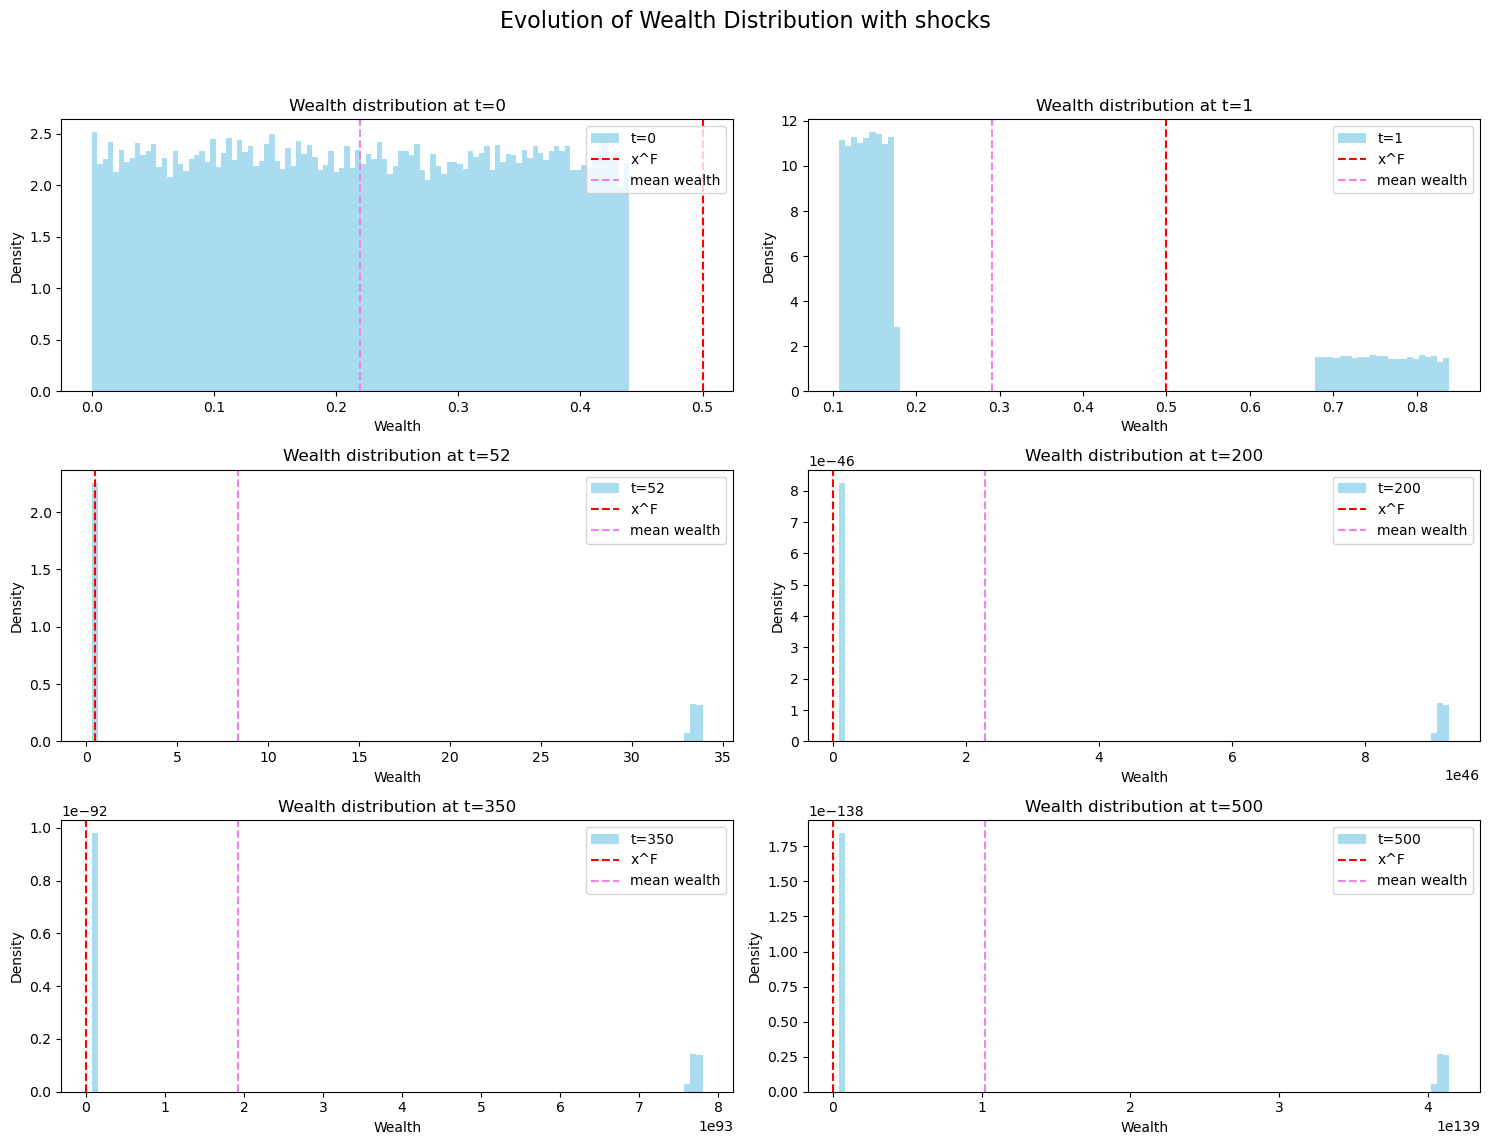

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12)) # Create a 3x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, t_val in enumerate([0, 1, 52, 200, 350, 500]):
    t = t_val
    ax = axes[i]
    mean=np.mean(history[t])
    ax.hist(history[t], bins=100, alpha=0.7, label=f"t={t}", density=True, color='skyblue')
    ax.axvline(xF, color='red', linestyle='--', label="x^F")
    #ax.axvline(xp(mu, r, alpha, A_up_bar, Ybar), color='blue', linestyle='--', label="x^P")
    ax.axvline(mean, color='violet', linestyle='--', label="mean wealth")
    ax.legend()
    ax.set_title(f"Wealth distribution at t={t}")
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Density")
    print('mean wealth at t=',t, ':\t', mean)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Evolution of Wealth Distribution with shocks', fontsize=16) # Add a main title to the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()

#### Fine tuning dei parametri s.t. a_L senza shock sia sotto la bisettrice in x^F e che a_R(1) >1, aR(0)<1 e con shock tutto sotto => n^p_fin=1

In [26]:
p = 0.5
gamma_p = 0.8
gamma_up = 0.9

A_up_bar = 1.1
A_p_bar = 1.3
F=1
xF= F/(1+mu)
n_p=0

print ('Condizione 35 expected ',Primacondizione(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 expected ',Secondacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 37(np=0) expected ',Terzacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) expected ',Quartacondizione(mu, r, alpha, xF, A_p_bar, Ybar))
print('')
print ('Condizione 35 no shock ',Primacondizionenoshock(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 no shock ',Secondacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 37(np=0) no shock',Terzacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) no shock ',Quartacondizionenoshock(mu, r, alpha, xF, A_p_bar, Ybar))
print('')
print ('Condizione 35 shock ',Primacondizioneshock(mu, r, alpha, xF, A_up_bar, Ybar))
print ('Condizione 36 shock ',Secondacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar ))
print ('Condizione 37(np=0) shock',Terzacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar))
print ('Condizione 47(np=1) shock ', Quartacondizioneshock(mu, r, alpha, xF, A_p_bar, Ybar))

Condizione 35 expected  True
Condizione 36 expected  False
Condizione 37(np=0) expected  True
Condizione 47(np=1) expected  True

Condizione 35 no shock  True
Condizione 36 no shock  True
Condizione 37(np=0) no shock True
Condizione 47(np=1) no shock  True

Condizione 35 shock  True
Condizione 36 shock  False
Condizione 37(np=0) shock True
Condizione 47(np=1) shock  False


Distribuzione con n^p_in>0

In [50]:
T=500
yhigh=5
y = uniform_initial(N, low=0, high=yhigh)
n_p = np.mean(y > xF)
print('n_p_initial=', n_p)
history = simulate_shock(lambda N: uniform_initial(N, low=0, high=yhigh), update_wealth, T)
n_p= np.mean(history[T]>xF)
meanwealth= np.mean(history[T])

print('mean final wealth =', meanwealth)
print('n_p_final=', n_p)

fig, axes = plt.subplots(3, 2, figsize=(15, 12)) # Create a 3x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, t_val in enumerate([0, 1, 4, 100, 350, 500]):
    t = t_val
    ax = axes[i]
    mean=np.mean(history[t])
    ax.hist(history[t], bins=100, alpha=0.7, label=f"t={t}", density=True, color='skyblue')
    #ax.axvline(xF, color='red', linestyle='--', label="x^F")
    #ax.axvline(xp(mu, r, alpha, A_up_bar, Ybar), color='blue', linestyle='--', label="x^P")
    ax.axvline(mean, color='violet', linestyle='--', label="mean wealth")
    ax.legend()
    ax.set_title(f"Wealth distribution at t={t}")
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Density")
    print('mean wealth at t=',t, ':\t', mean)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Evolution of Wealth Distribution with shocks', fontsize=16) # Add a main title to the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()

n_p_initial= 0.93278
mean final wealth = 2.2472125927809645e+151
n_p_final= 1.0


Distribuzione con nP_in=0

n_p_initial= 0.0
mean final wealth = 1.0469699413383096e+146
n_p_final= 1.0
mean wealth at t= 0 :	 0.1498389834228131
mean wealth at t= 1 :	 0.2578609578328156
mean wealth at t= 4 :	 0.13430931427600903
mean wealth at t= 100 :	 9.667517077637311e+22
mean wealth at t= 350 :	 3.123153260228849e+98
mean wealth at t= 500 :	 1.0469699413383096e+146


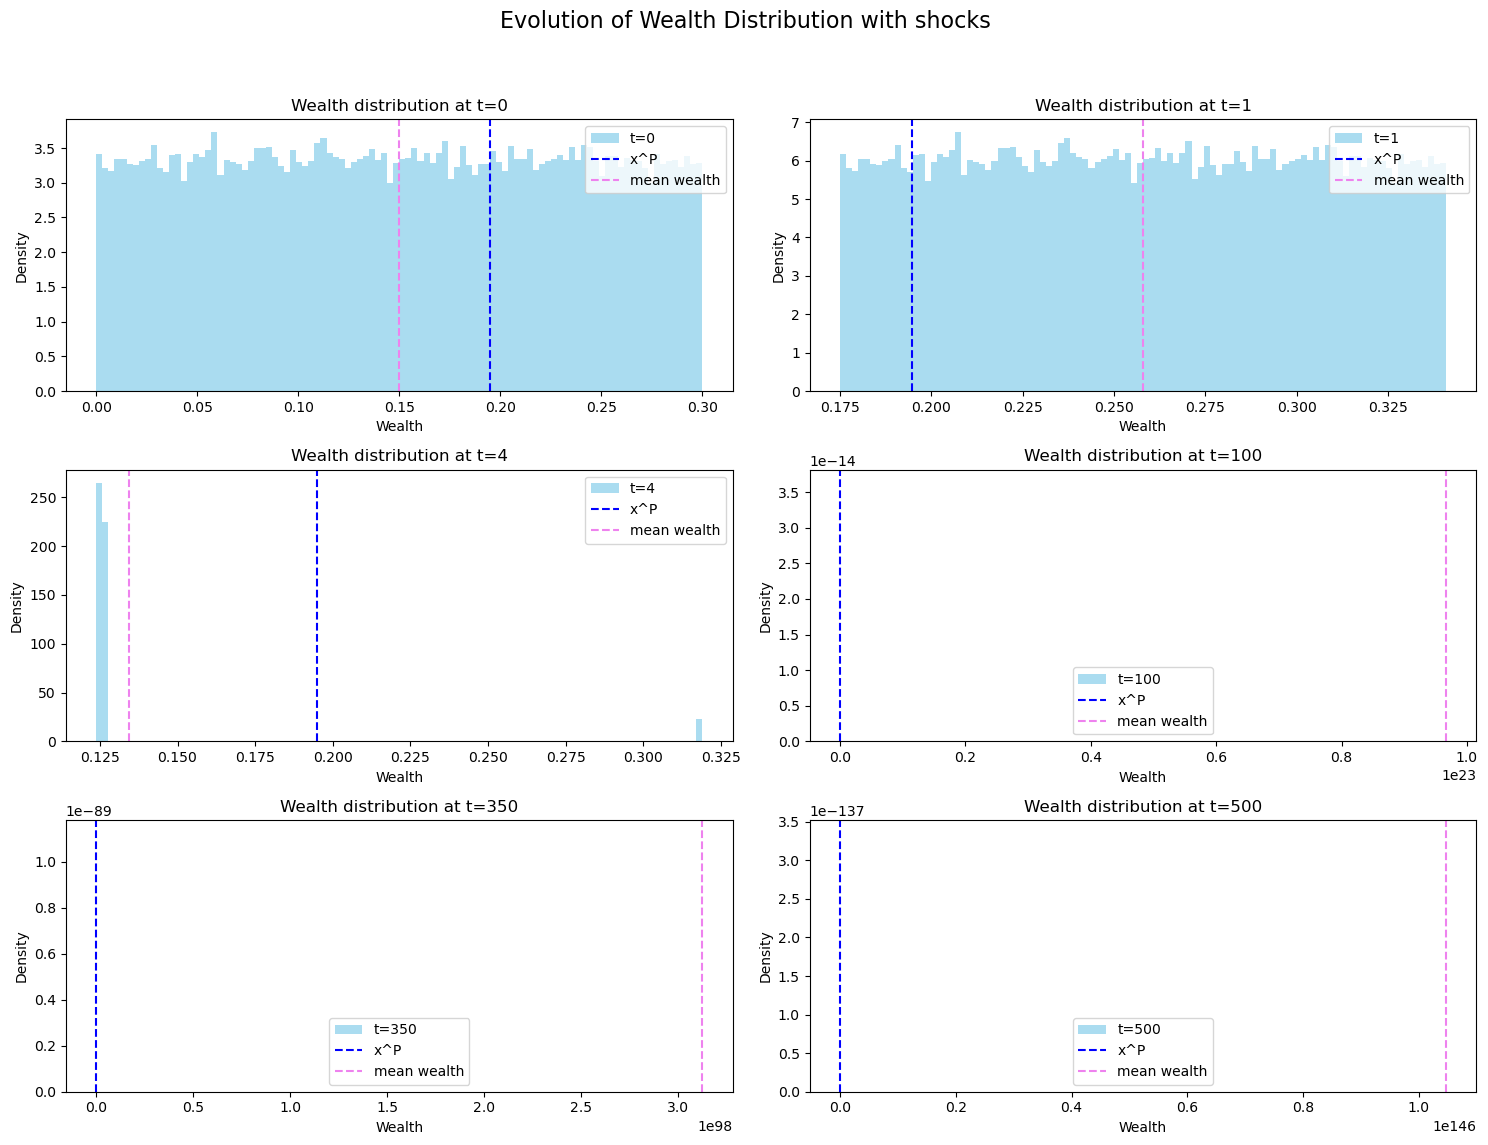

In [54]:
T=500
yhigh=0.3
y = uniform_initial(N, low=0, high=yhigh)
n_p = np.mean(y > xF)
print('n_p_initial=', n_p)
history = simulate_shock(lambda N: uniform_initial(N, low=0, high=yhigh), update_wealth, T)
n_p= np.mean(history[T]>xF)
meanwealth= np.mean(history[T])

print('mean final wealth =', meanwealth)
print('n_p_final=', n_p)

fig, axes = plt.subplots(3, 2, figsize=(15, 12)) # Create a 3x2 grid of subplots
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, t_val in enumerate([0, 1, 4, 100, 350, 500]):
    t = t_val
    ax = axes[i]
    mean=np.mean(history[t])
    ax.hist(history[t], bins=100, alpha=0.7, label=f"t={t}", density=True, color='skyblue')
    #ax.axvline(xF, color='red', linestyle='--', label="x^F")
    ax.axvline(xp(mu, r, alpha, A_up_bar, Ybar), color='blue', linestyle='--', label="x^P")
    ax.axvline(mean, color='violet', linestyle='--', label="mean wealth")
    ax.legend()
    ax.set_title(f"Wealth distribution at t={t}")
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Density")
    print('mean wealth at t=',t, ':\t', mean)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Evolution of Wealth Distribution with shocks', fontsize=16) # Add a main title to the figure
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlapping titles/labels and make space for suptitle
plt.show()